# Dynamics Python Labs
### Created by Cait Roufa
### Lab 3 - LEA

In this lab, you will be determining the afternoon temperature at 850 hPa in Rockford, IL using advection and total and local derivatives.

### Learning Objectives: 
Use a morning analysis of 850-hPa temperature and winds to:
1) compute the **advection tendency** at Rockford, IL,  
2) estimate the **temperature change** by afternoon (≈ 6 hours later), and  
3) compare with the verifying analysis (if available in our download).

**Key ideas**
- **Eulerian (fixed point):** local tendency at a location  
- **Advection tendency:** $-\,\mathbf{v}\cdot\nabla_h T$ (warming > 0, cooling < 0 at the fixed point)  
- **Total (Lagrangian) derivative:** $DT/Dt = \partial T/\partial t + \mathbf{v}\cdot\nabla_h T$ (parcel’s rate of change)

#### Step 1 - Import Packages
Import your packages. This cell is safe to re-run at any time.

In [1]:
# Core scientific Python
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Data access & meteorology helpers
from siphon.catalog import TDSCatalog
from siphon.ncss import NCSS
import metpy.calc as mpcalc
from metpy.units import units

# We’ll use MetPy's xarray accessors for unit conversion (no pint-xarray plugin required).

#### Step 2 - Configure Location, Time, and Data Source
We set up configuration of the location, time window, and small domain box

In [2]:
# Rockford, IL (RFD airport approx)
RFD_LAT = 42.20   # degrees North
RFD_LON = -89.10  # degrees East (negative = West)

# We'll define "morning" as ~12 UTC and "afternoon" as ~6 hours later.
MORNING_HOUR_UTC = 12        # target morning hour (UTC)
LEAD_HOURS = 6               # morning -> afternoon window (hours)

# Tiny domain around Rockford to keep downloads small (adjust if needed)
BOX_N = 46   # north lat
BOX_S = 38   # south lat
BOX_W = -96  # west lon
BOX_E = -84  # east lon

# Data source: Unidata THREDDS GFS 0.25° ("Best" time series) - public
CAT_URL = "https://thredds.ucar.edu/thredds/catalog/grib/NCEP/GFS/Global_0p25deg/catalog.xml"
DATASET_NAME = "Best GFS Quarter Degree Forecast Time Series"

print("Setup complete. Next: download a small time window around morning and afternoon.")

Setup complete. Next: download a small time window around morning and afternoon.


#### Step 3 - Download Data
Download a small time window that spans morning through afternoon. Our strategy is to:
1. Pick the most recent "morning" time we think exists (today ~12Z; if it's too early UTC, use yesterday).
2. Request about a 9 hour range so we can pick the actual available times nearest 12Z and 18Z.
3. Keep the domain tight around Rockford to avoid huge downloads.

In [3]:
# 1) Choose the morning date safely
now_utc = pd.Timestamp.utcnow()
today_utc = now_utc.normalize()

# If it's before ~11 UTC now, use yesterday's morning (latest 12Z may not be posted yet)
if now_utc.hour < MORNING_HOUR_UTC - 1:
    morning_date = today_utc - pd.Timedelta(days=1)
else:
    morning_date = today_utc

t0_target = morning_date + pd.Timedelta(hours=MORNING_HOUR_UTC)         # ~12Z morning
t_end     = t0_target + pd.Timedelta(hours=9)                            # window end (gives several times)

# 2) Open THREDDS dataset and build query
cat = TDSCatalog(CAT_URL)
best = cat.datasets[DATASET_NAME]
ncss = NCSS(best.access_urls["NetcdfSubset"])

q = ncss.query()
q.variables("Temperature_isobaric", "u-component_of_wind_isobaric", "v-component_of_wind_isobaric")
q.add_lonlat()
q.accept("netcdf4")
q.vertical_level(85000)                              # 850 hPa (Pa)
q.lonlat_box(north=BOX_N, south=BOX_S, east=BOX_E, west=BOX_W)
q.time_range(t0_target.to_pydatetime(), t_end.to_pydatetime())

# 3) Fetch data and parse with xarray+MetPy
data = ncss.get_data(q)
ds = xr.open_dataset(xr.backends.NetCDF4DataStore(data)).metpy.parse_cf()

# If only one time came back (rare with a 9h window), try the previous day’s morning
if ds.sizes.get("time", 1) < 2:
    print("Only one time returned; trying the previous day's morning window...")
    morning_date = morning_date - pd.Timedelta(days=1)
    t0_target = morning_date + pd.Timedelta(hours=MORNING_HOUR_UTC)
    t_end     = t0_target + pd.Timedelta(hours=9)
    q = ncss.query()
    q.variables("Temperature_isobaric", "u-component_of_wind_isobaric", "v-component_of_wind_isobaric")
    q.add_lonlat(); q.accept("netcdf4")
    q.vertical_level(85000)
    q.lonlat_box(north=BOX_N, south=BOX_S, east=BOX_E, west=BOX_W)
    q.time_range(t0_target.to_pydatetime(), t_end.to_pydatetime())
    data = ncss.get_data(q)
    ds = xr.open_dataset(xr.backends.NetCDF4DataStore(data)).metpy.parse_cf()

# Show what we actually got
print("Times retrieved (UTC):")
for t in pd.to_datetime(ds["time"].values):
    print("  ", t)

/home/croufa/.local/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.26.0
  warnings.warn(


Times retrieved (UTC):
   2025-09-08 12:00:00
   2025-09-08 15:00:00
   2025-09-08 18:00:00
   2025-09-08 21:00:00


#### Step 4 - Select times from downloaded data
Pick "morning" and "afternoon" from what we downloaded. We also need to fix a problem here:
1. Dataset times can be timezone-aware (UTC) while our "target" times are timezone naive.
2. Subtracting tz-aware and tz-naive timestamps raises: "Cannot subtract tz-naive and tz-aware..."
So our solution is to normaize BOTH the dataset time and our target times to the SAME standard: UTC time zone, then drop tz info (UTC-naive) so arithmetic is safe.

In [4]:
def to_utc_naive_index(times_like):
    """
    Convert an array-like of datetimes to a Pandas DatetimeIndex that is:
      1) in UTC
      2) timezone *removed* (tz-naive), but still representing UTC clock time.
    """
    t = pd.to_datetime(times_like)
    # If it has no timezone, localize to UTC; otherwise convert to UTC
    if getattr(t, 'tz', None) is None:
        t = t.tz_localize('UTC')
    else:
        t = t.tz_convert('UTC')
    # Drop timezone info so we can subtract safely later
    return t.tz_localize(None)

def to_utc_naive_ts(ts_like):
    """
    Convert a single timestamp to UTC-naive (same idea as above).
    """
    t = pd.to_datetime(ts_like)
    if t.tzinfo is None:
        t = t.tz_localize('UTC')
    else:
        t = t.tz_convert('UTC')
    return t.tz_localize(None)

def nearest_time_idx(times, target_ts):
    """
    Return (index, smallest_abs_difference) for the dataset times closest to target_ts.
    Inputs can be tz-aware or tz-naive; we normalize both.
    """
    times_pd = to_utc_naive_index(times)     # UTC-naive DatetimeIndex
    target   = to_utc_naive_ts(target_ts)    # UTC-naive Timestamp
    diffs = np.abs(times_pd - target)
    idx = int(np.argmin(diffs))
    return idx, diffs.min()

# ---- Use the helpers to pick t0 (morning) and t1 (afternoon) ----
time_vals = ds["time"].values
if time_vals.size < 2:
    raise ValueError("Need at least 2 times in the dataset. Re-run the download cell.")

# Choose t0 near morning target
idx0, diff0 = nearest_time_idx(time_vals, t0_target)
# Define "afternoon" as t0 + LEAD_HOURS, then pick closest available time
t0_norm = to_utc_naive_ts(time_vals[idx0])              # UTC-naive Timestamp for the chosen morning
t1_target = t0_norm + pd.Timedelta(hours=LEAD_HOURS)
idx1, diff1 = nearest_time_idx(time_vals, t1_target)

# Final normalized (UTC-naive) times we will use everywhere
t0 = to_utc_naive_ts(time_vals[idx0])
t1 = to_utc_naive_ts(time_vals[idx1])

print(f"Chosen t0 (≈ morning):     {t0}  [closest to {to_utc_naive_ts(t0_target)}; offset {diff0}]")
print(f"Chosen t1 (≈ afternoon):   {t1}  [closest to {t1_target}; offset {diff1}]")

# Compute Δt with units (seconds) using the normalized timestamps
dt = (t1 - t0).total_seconds() * units("s")
print("Δt used =", dt.to("hour"))

Chosen t0 (≈ morning):     2025-09-08 12:00:00  [closest to 2025-09-08 12:00:00; offset 0 days 00:00:00]
Chosen t1 (≈ afternoon):   2025-09-08 18:00:00  [closest to 2025-09-08 18:00:00; offset 0 days 00:00:00]
Δt used = 6.0 hour


#### Step 5 - Define variables and set units
Next we need to prepare our variables with the proper units and choose the Rockford grid cell. We'll convert units cleanly, ensuring lon/lat order is increasing, and then pick the nearest grid cell to Rockford's coordinates. We'll also handle datasets that use 0...360 deg longitudes.

In [5]:
# Grab variables at 850 hPa
T = ds["Temperature_isobaric"]
U = ds["u-component_of_wind_isobaric"]
V = ds["v-component_of_wind_isobaric"]

# Convert to consistent units (MetPy handles units on xarray objects)
Tq = T.metpy.quantify().metpy.convert_units("kelvin")
Uq = U.metpy.quantify().metpy.convert_units("m/s")
Vq = V.metpy.quantify().metpy.convert_units("m/s")

# Sort coordinates so latitude & longitude increase (avoids sign confusion)
Tq = Tq.sortby("latitude").sortby("longitude")
Uq = Uq.sortby("latitude").sortby("longitude")
Vq = Vq.sortby("latitude").sortby("longitude")

# 1D longitude/latitude arrays for this subset (MetPy helps extract them)
lons = Tq.metpy.longitude.values
lats = Tq.metpy.latitude.values

# Helper: nearest longitude index that understands wrap-around at 180°
def nearest_lon_idx(lons_1d, lon_target_deg):
    # Compute minimal angular difference on a circle (0..360 wrap)
    diffs = np.abs(((lons_1d - lon_target_deg + 180) % 360) - 180)
    return int(np.argmin(diffs))

# If dataset uses 0..360 longitudes and our target is -89.1, the helper still works.
i = nearest_lon_idx(lons, RFD_LON)
j = int(np.argmin(np.abs(lats - RFD_LAT)))

print("Longitude array min/max:", float(np.nanmin(lons)), "→", float(np.nanmax(lons)))
print(f"Chosen Rockford grid cell: lon={float(lons[i]):.2f}°, lat={float(lats[j]):.2f}°")

Longitude array min/max: 264.0 → 276.0
Chosen Rockford grid cell: lon=271.00°, lat=42.25°


#### Step 6 - Calculate advection and estimate final temp
Now we are ready to compute the advection tendency at t0 and estimate the afternoon temp. Math we'll use at the fixed grid cell:
1. Advection tendency (Eulerian): -(u * dT/dx + v * dT/dy)  [K/s]
2. Estimated afternoon temp: T_est = T(t0) + (advection_tendency) * Δt
We'll also compute the actual analysis temp at t1 (if available) to compare.

In [6]:
# 2D slices (lat, lon) at t0 and t1
T0 = Tq.sel(time=t0).squeeze()  # 2D (lat, lon)
T1 = Tq.sel(time=t1).squeeze()
U0 = Uq.sel(time=t0).squeeze()
V0 = Vq.sel(time=t0).squeeze()

# Compute advection tendency at t0 over the whole small domain
# mpcalc.advection returns + (v·∇T) in K/s, so we NEGATE it to get the "tendency" form -(u dT/dx + v dT/dy)
advec_tendency = -mpcalc.advection(T0, u=U0, v=V0, x_dim="longitude", y_dim="latitude")  # K/s

# Values at Rockford grid cell
T0_pt = float(T0.values[j, i])                         # K
advec_pt_Ks = float(advec_tendency.values[j, i])       # K/s

# Convert advection tendency to K/hour (easier to interpret)
advec_Khr = advec_tendency.metpy.convert_units("kelvin/hour")
advec_pt_Khr = float(advec_Khr.values[j, i])           # K/hr

# Estimate afternoon temperature at the fixed grid cell using advection-only
T1_est = T0_pt + advec_pt_Ks * dt.m  # Δt in seconds
print(f"T at t0 (morning)      : {T0_pt:.2f} K")
print(f"Advection tendency     : {advec_pt_Khr:+.2f} K/hr  (positive=warming, negative=cooling)")
print(f"Estimated T by afternoon: {T1_est:.2f} K  (advection-only)")

# Actual analysis at t1 (if available in our window)
T1_pt = float(T1.values[j, i])
print(f"Actual T at t1         : {T1_pt:.2f} K")
print(f"Error (estimate - actual): {T1_est - T1_pt:+.2f} K")

T at t0 (morning)      : 279.19 K
Advection tendency     : -0.21 K/hr  (positive=warming, negative=cooling)
Estimated T by afternoon: 277.90 K  (advection-only)
Actual T at t1         : 279.92 K
Error (estimate - actual): -2.02 K


/anaconda3/envs/pyEAE/lib/python3.9/site-packages/metpy/xarray.py:1473: UserWarning: Vertical dimension number not found. Defaulting to (..., Z, Y, X) order.
  warnings.warn(


#### Step 7 - Plot temp and winds at Rockford, IL
We'll quickly plot the 850 hPa temp contours in degC, 850 hPa winds as quivers/arrows, and Rockford's grid cell location at t0.

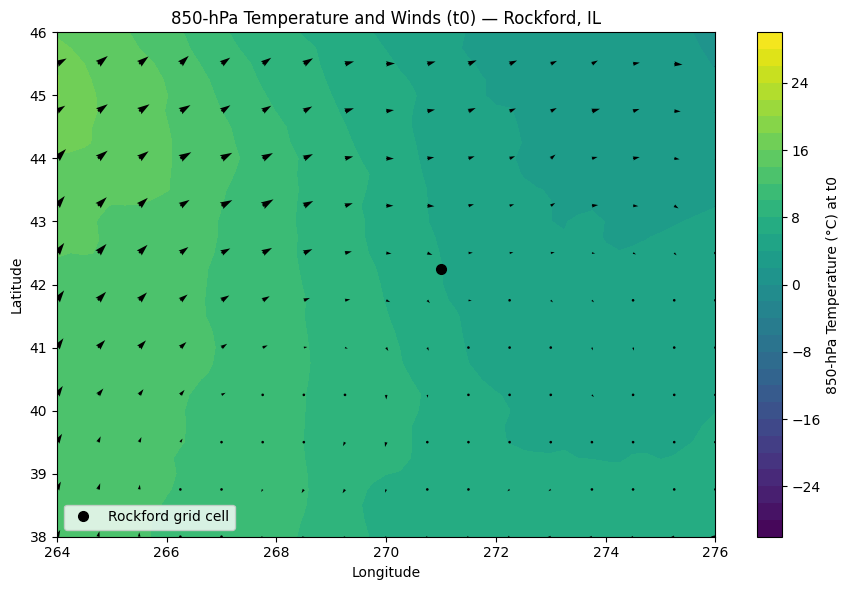

In [7]:
# Convert temperature to °C for plotting and drop units to plain floats
T0_C = T0.metpy.convert_units("degC").metpy.dequantify().values  # 2D ndarray
U0_np = U0.metpy.dequantify().values
V0_np = V0.metpy.dequantify().values

# Build 2D lon/lat grids for quiver convenience
LON2D, LAT2D = np.meshgrid(lons, lats)  # shapes match (lat x lon)

plt.figure(figsize=(9, 6))

# Filled contours for temperature at t0
levels = np.arange(-30, 31, 2)  # °C, adjust if your day is much warmer/colder
cs = plt.contourf(lons, lats, T0_C, levels=levels)
plt.colorbar(cs, label="850-hPa Temperature (°C) at t0")

# Wind vectors (downsample so it’s readable)
step = 3
plt.quiver(
    LON2D[::step, ::step], LAT2D[::step, ::step],
    U0_np[::step, ::step], V0_np[::step, ::step],
    scale=700
)

# Mark Rockford point
plt.plot(lons[i], lats[j], 'ko', ms=7, label='Rockford grid cell')

plt.title("850-hPa Temperature and Winds (t0) — Rockford, IL")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Questions

1. Does the wind direction relative to isotherms explain the SIGN of your advection tendency at Rockford?
2. Why might this advection-only estimate differ from the actual result? Even if they are the same, please speculate as to other influences on the afternoon temperature.

### Step 8 - Plot horizontal temp advection
Let's plot the horizontal temperature advection over the domain, so that we can visualize where warm (positive) and cold (negative) advection are strongest. We will be resuing the variables from earlier cells (Tq, Uq, Vq, lons, lats, t0, i, and j), so if you restarted the kernel, make sure to re-run previous cells before this one.

/anaconda3/envs/pyEAE/lib/python3.9/site-packages/metpy/xarray.py:1473: UserWarning: Vertical dimension number not found. Defaulting to (..., Z, Y, X) order.
  warnings.warn(


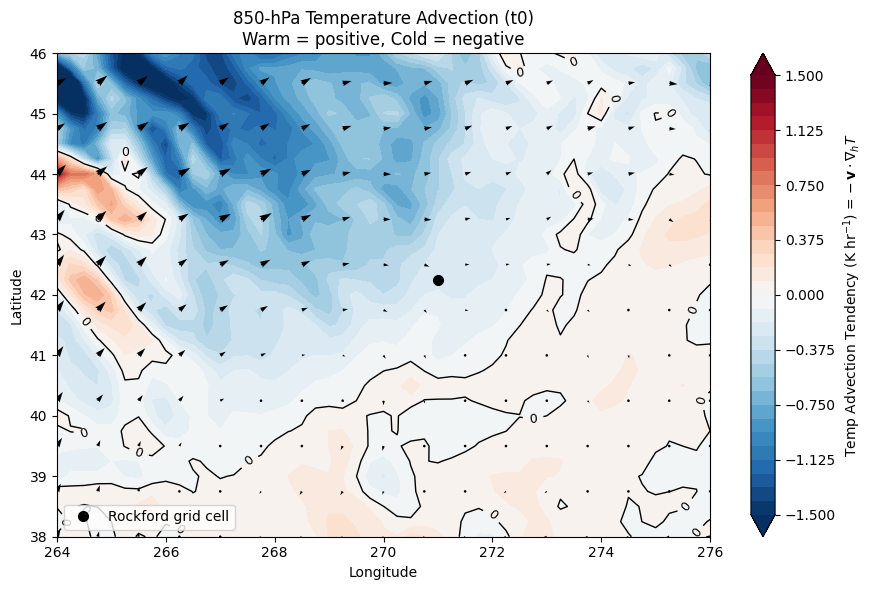

In [8]:
# 1) Make sure we have the 2D fields at the "morning" time t0 (lat x lon)
T0 = Tq.sel(time=t0).squeeze()
U0 = Uq.sel(time=t0).squeeze()
V0 = Vq.sel(time=t0).squeeze()

# 2) Compute the advection tendency field at t0 (units: K/s)
#    mpcalc.advection returns + (v · ∇T); we NEGATE to get the tendency form -(u dT/dx + v dT/dy)
advec_tendency = -mpcalc.advection(T0, u=U0, v=V0, x_dim="longitude", y_dim="latitude")  # K/s

# 3) Convert to K/hour for interpretability and drop units to plot easily
advec_Khr_da = advec_tendency.metpy.convert_units("kelvin/hour")  # still a DataArray with units
advec_Khr = advec_Khr_da.metpy.dequantify().values                # plain numpy array

# 4) Build lon/lat 2D grids for quiver (if not already built)
LON2D, LAT2D = np.meshgrid(lons, lats)

# 5) Choose a symmetric color scale centered on 0.
#    We set the half-range (vmax) adaptively from the data, but clamp to a reasonable max (e.g., ±6 K/hr).
vmax = float(np.nanpercentile(np.abs(advec_Khr), 98))  # robust to outliers
vmax = min(6.0, max(1.5, round(vmax, 1)))             # keep it readable
levels = np.linspace(-vmax, vmax, 33)                 # smooth color steps

# 6) Make the plot
plt.figure(figsize=(9, 6))

# Filled contours of advection tendency (K/hr)
cf = plt.contourf(lons, lats, advec_Khr, levels=levels, cmap="RdBu_r", extend="both")
plt.colorbar(cf, label="Temp Advection Tendency (K hr$^{-1}$) = $-\\,\\mathbf{v}\\cdot\\nabla_h T$")

# Zero-advection contour (transition between warm/cold advection)
cz = plt.contour(lons, lats, advec_Khr, levels=[0.0], colors="k", linewidths=1.0)
plt.clabel(cz, fmt="0", inline=True, fontsize=9)

# Wind vectors (downsample so it’s readable)
U0_np = U0.metpy.dequantify().values
V0_np = V0.metpy.dequantify().values
step = 3
plt.quiver(
    LON2D[::step, ::step], LAT2D[::step, ::step],
    U0_np[::step, ::step], V0_np[::step, ::step],
    scale=700
)

# Mark Rockford's grid cell
plt.plot(lons[i], lats[j], 'ko', ms=7, label='Rockford grid cell')

plt.title("850-hPa Temperature Advection (t0)\nWarm = positive, Cold = negative")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Questions
1. Where are the strongest warm advection (red) and cold advection (blue) corridors?
2. Base only on Eulerian advection plotted here, where in the domain would you expect the greatest temperature change by afternoon?
2. How does the advection sign at Rockford relate to your final temperature estimate from earlier?

## Challenge!

Repeat the analysis for 700 hPa. How do the magnitude and sign of advdection change relative to 850 hPa?

HINT: You will need to copy and paste code into cells bellow, starting with Step 3 above. Make changes to get 700 hPa data.